# Repressilator: a synthetic genetic oscillator

The repressilator (Elowitz & Leibler, *Nature* 2000) is a synthetic gene
circuit built from three genes arranged in an odd-length inhibitory cycle:
`A` represses `B`, `B` represses `C`, and `C` represses `A`. When
repression is sufficiently cooperative (Hill coefficient *n* > 2 for a
protein-only model) and the maximum synthesis rate is large relative to the
degradation rate, the circuit is *unstable at its symmetric fixed point* and
settles instead onto a stable **limit cycle** — sustained, autonomous
oscillations in which each protein rises and falls in turn, separated by
equal 120° phase shifts.

Unlike the toggle switch, no external inducer is needed: the repressilator
oscillates on its own once the parameters are in the oscillatory regime.
This notebook shows the oscillation in a deterministic (ODE) single cell,
visualizes the limit cycle in the phase plane, compares it with a stochastic
(Gillespie SSA) simulation, and finally animates a small growing colony
cycling through all three protein colors.


In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, ReactionNetwork, Simulation, visualize
from multicellular.core.reactions import Reaction

plt.rcParams["figure.dpi"] = 100


## 1. The repressilator reaction network

Each gene's synthesis rate follows a Hill-repression law:

```
synthesis rate = beta / (1 + (repressor / K) ** n)
```

At low repressor the gene fires near maximally at rate `beta`; as the
repressor exceeds its half-repression constant `K`, output falls off with
cooperativity *n*. The symmetric fixed point is:

```
x* = beta / (1 + x*^n)   (same for A, B, C by symmetry)
```

Linearizing around this fixed point, oscillations appear when the
loop gain `n · x*^n / (1 + x*^n) > 2`. This requires *n* > 2; here
*n* = 4 and *beta* = 10 place the circuit comfortably in the oscillatory
regime (loop gain ≈ 3.3 at the fixed point).


In [2]:
def repression_rate(reactant_conc, product_conc, catalyst_conc, params):
    repressor = catalyst_conc.get(params["repressor"], 0.0)
    return params["beta"] / (1.0 + (repressor / params["K"]) ** params["n"])


def build_repressilator_network(simulation_method="ODE", beta=10.0, K=1.0, n=4.0, k_deg=1.0):
    """Three-gene inhibitory cycle: A -| B -| C -| A."""
    gene_a = Reaction(
        {}, {"A": 1}, catalysts=["C"], rate_law_type="custom",
        custom_rate_law=repression_rate,
        rate_params={"repressor": "C", "K": K, "n": n, "beta": beta},
    )
    gene_b = Reaction(
        {}, {"B": 1}, catalysts=["A"], rate_law_type="custom",
        custom_rate_law=repression_rate,
        rate_params={"repressor": "A", "K": K, "n": n, "beta": beta},
    )
    gene_c = Reaction(
        {}, {"C": 1}, catalysts=["B"], rate_law_type="custom",
        custom_rate_law=repression_rate,
        rate_params={"repressor": "B", "K": K, "n": n, "beta": beta},
    )
    deg_a = Reaction({"A": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
    deg_b = Reaction({"B": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
    deg_c = Reaction({"C": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
    return ReactionNetwork(
        "repressilator",
        {"gene_a": gene_a, "gene_b": gene_b, "gene_c": gene_c,
         "deg_a": deg_a, "deg_b": deg_b, "deg_c": deg_c},
        simulation_method=simulation_method,
    )


## 2. Deterministic oscillations (single cell, ODE)

Starting slightly off the unstable symmetric fixed point, the system spirals
outward and locks onto the limit cycle within a few periods. Each protein
traces the same waveform, offset by one-third of a period (~120°) from its
neighbor.


In [3]:
cell = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0],
    network=build_repressilator_network("ODE"), growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("A", 3.0)
cell.set_concentration("B", 0.1)
cell.set_concentration("C", 0.1)

env = Environment(shape=(5, 5), bounds=(50.0, 50.0))
colony = Colony([cell], env)
sim = Simulation(colony, dt=0.05, t_max=60.0)
df_ode = sim.run(show_progress=False)

# Estimate period from peaks of A in the steady-state portion.
steady = df_ode[df_ode["time"] > 10.0]
a_vals = steady["A"].values
peaks = [i for i in range(1, len(a_vals) - 1) if a_vals[i] > a_vals[i - 1] and a_vals[i] > a_vals[i + 1]]
if len(peaks) > 1:
    times = steady["time"].values
    period = np.mean([times[peaks[i + 1]] - times[peaks[i]] for i in range(len(peaks) - 1)])
    print(f"estimated period: {period:.2f} time units")
    print(f"A amplitude: {a_vals[peaks].mean():.2f} (peak) / {a_vals.min():.2f} (trough)")


estimated period: 6.01 time units
A amplitude: 7.91 (peak) / 0.36 (trough)


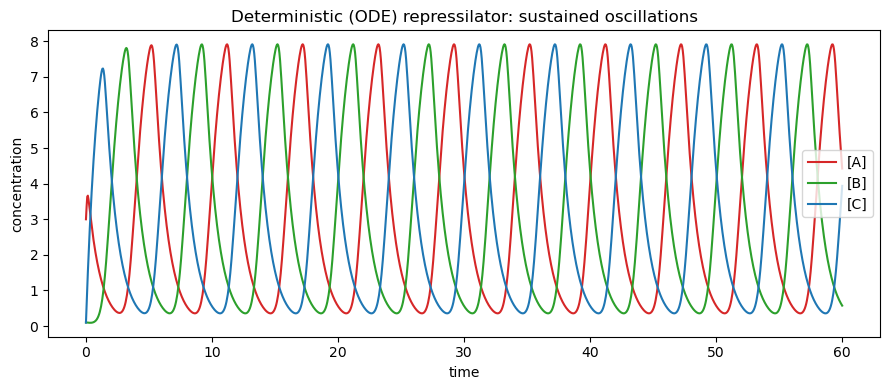

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ode["time"], df_ode["A"], color="tab:red",   label="[A]")
ax.plot(df_ode["time"], df_ode["B"], color="tab:green", label="[B]")
ax.plot(df_ode["time"], df_ode["C"], color="tab:blue",  label="[C]")
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title("Deterministic (ODE) repressilator: sustained oscillations")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Limit cycle in the phase plane

Projecting the three-dimensional trajectory onto the `(A, B)` plane reveals
the geometry of the oscillation: an initial transient spirals outward from
the unstable fixed point and converges onto a closed **limit cycle**. The
same loop is traced indefinitely once the transient decays, confirming the
oscillations are self-sustaining, not a ringing response.


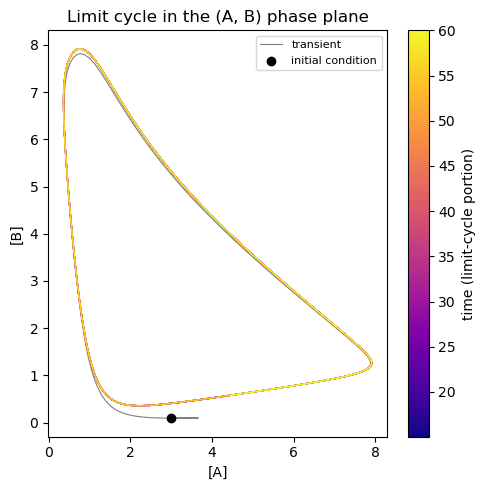

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

transient = df_ode[df_ode["time"] <= 15.0]
limit_cycle = df_ode[df_ode["time"] > 15.0]

ax.plot(transient["A"], transient["B"], color="gray", linewidth=0.8, label="transient", zorder=1)

# Color the limit-cycle segment by time so the direction of travel is visible.
lc_A = limit_cycle["A"].values
lc_B = limit_cycle["B"].values
lc_t = limit_cycle["time"].values
t_norm = (lc_t - lc_t.min()) / (lc_t.max() - lc_t.min())
for i in range(len(lc_A) - 1):
    ax.plot(lc_A[i:i+2], lc_B[i:i+2], color=plt.cm.plasma(t_norm[i]), linewidth=1.0, zorder=2)

ic = df_ode[["A", "B"]].iloc[0].values
ax.scatter(ic[0], ic[1], color="black", zorder=5, label="initial condition")
sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(lc_t.min(), lc_t.max()))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="time (limit-cycle portion)")
ax.set_xlabel("[A]")
ax.set_ylabel("[B]")
ax.set_title("Limit cycle in the (A, B) phase plane")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4. Stochastic oscillations (Gillespie SSA)

With `simulation_method="SSA"` the same network is advanced by exact
Gillespie stochastic simulation. Using a larger cell (`length=8.0`,
volume ≈ 6.8 µm³) keeps molecule counts low enough for visible noise
without extinguishing the oscillation. Two signatures of molecular noise
appear clearly against the deterministic (dashed) reference: **amplitude
fluctuations** from shot noise in each burst, and **phase diffusion** —
stochastic timing jitter that accumulates over cycles so the SSA trace drifts
slowly out of phase with the deterministic one.


In [6]:
cell_ssa = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0], length=8.0,
    network=build_repressilator_network("SSA"), growth_rate=0.0, rng=np.random.default_rng(3),
)
cell_ssa.set_concentration("A", 3.0)
cell_ssa.set_concentration("B", 0.1)
cell_ssa.set_concentration("C", 0.1)

colony_ssa = Colony([cell_ssa], Environment(shape=(5, 5), bounds=(50.0, 50.0)))
sim_ssa = Simulation(colony_ssa, dt=0.05, t_max=60.0)
df_ssa = sim_ssa.run(show_progress=False)

print(f"cell volume: {cell_ssa.compute_volume():.2f} um^3")


cell volume: 6.81 um^3


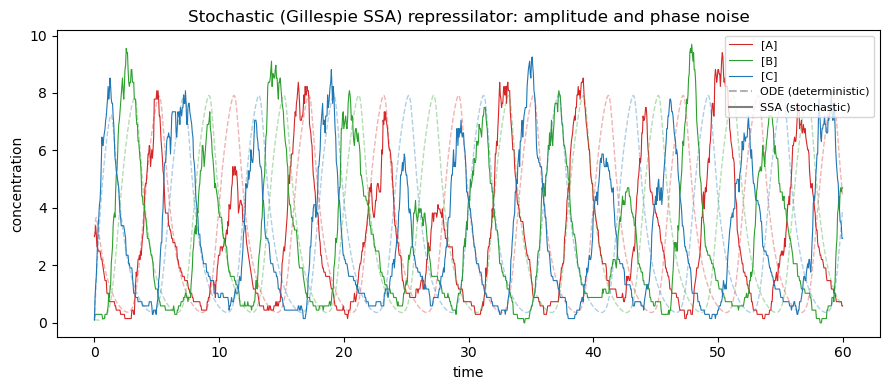

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for species, color in [("A", "tab:red"), ("B", "tab:green"), ("C", "tab:blue")]:
    ax.plot(df_ode["time"], df_ode[species], "--", color=color, alpha=0.35, linewidth=1.0)
    ax.plot(df_ssa["time"], df_ssa[species], color=color, linewidth=0.8, label=f"[{species}]")
# Invisible proxy lines for legend entries
ax.plot([], [], "--", color="gray", alpha=0.6, label="ODE (deterministic)")
ax.plot([], [], color="gray", label="SSA (stochastic)")
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title("Stochastic (Gillespie SSA) repressilator: amplitude and phase noise")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## 5. A synchronized growing colony: animating the oscillator

Three-color `visualize()` maps `[A]` to red, `[B]` to green, and `[C]` to
blue, so the colony cycles through the full RGB spectrum as the repressilator
oscillates. Starting synchronized, cells divide while continuing to oscillate;
with deterministic dynamics they stay in phase, so the whole colony pulses
together. Growth dilution (`growth_rate=0.04`) adds a small effective
degradation on top of `k_deg`, slightly shortening the period but leaving
the circuit solidly in the oscillatory regime.


In [8]:
video_cells = [
    Cell(
        id=i, position=position, orientation=[1.0, 0.0], length=2.0,
        network=build_repressilator_network("ODE"), growth_rate=0.04,
        rng=np.random.default_rng(i),
    )
    for i, position in enumerate([[45.0, 50.0], [55.0, 50.0]])
]
for video_cell in video_cells:
    video_cell.set_concentration("A", 3.0)
    video_cell.set_concentration("B", 0.1)
    video_cell.set_concentration("C", 0.1)

colony_video = Colony(
    video_cells, Environment(shape=(10, 10), bounds=(100.0, 100.0)), k=10.0, drag=1.0
)
sim_video = Simulation(colony_video, dt=0.25, t_max=30.0)
df_video = sim_video.run(show_progress=False)

final = df_video[df_video["time"] == df_video["time"].max()]
print(f"colony grew from {len(video_cells)} to {int(final['alive'].sum())} living cells")


colony grew from 2 to 8 living cells


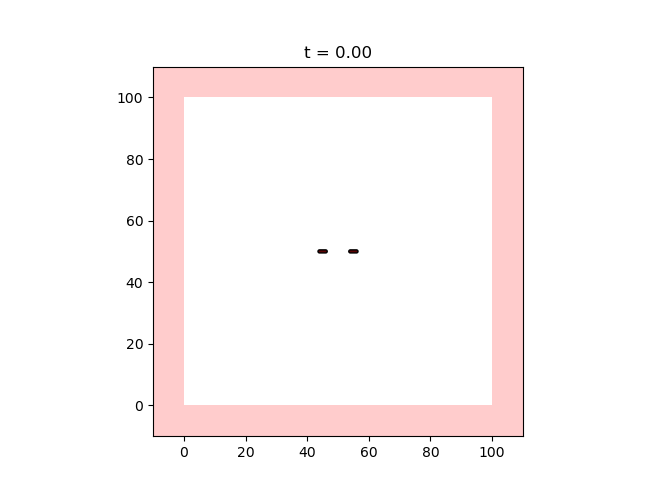

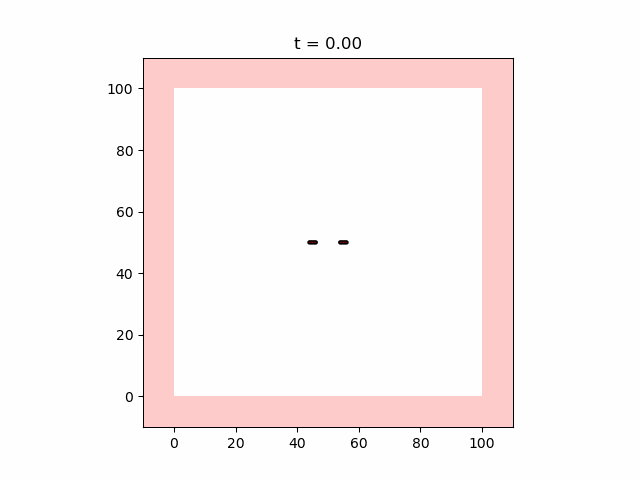

In [9]:
output_dir = tempfile.mkdtemp()
visualize(
    sim_video, red="A", green="B", blue="C",
    interval=80, save_path=output_dir, filename="repressilator.gif", show_progress=False,
)
Image(filename=os.path.join(output_dir, "repressilator.gif"))
